# Training the visual search model, start to finish

This notebook walks through the final model from this repository —
the one that predicts **where the eyes go first** during visual
search — and trains it from scratch **on the actual data**: 114,232
first eye movements from 333 people across 11 published experiments.

**Scope: the first saccade of each trial.** The eyes start at the
screen center, the display appears, and the model predicts where they
go. Later saccades bring in extra machinery (inhibition of return,
changing vantage points) and are out of scope here.

**Input and output.** For each trial the model receives: a picture of
the display (pixels), the goal (the color and shape to look for), and
the history of previous trials. It returns **a probability for every
item on the screen**. One predicted saccade is one random draw.

**Before running:** build the dataset once (needs the public data
from https://osf.io/q27ph/):

    python pool_data.py --data_dir ".../Data Files" --out_dir dataset
    python build_contexts.py

Needs `numpy`, `pandas`, `matplotlib`, `torch`. Training takes about
ten minutes on a laptop.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from front_end import render, shape_for, item_positions, IMG
from build_contexts import (opponency_contrast, shape_match_map,
                            template_axis, display_evidence, NBINS)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

pos, _ = item_positions(6)      # the six item slots (a ring)

## 1. Model structure

The model turns one display image (plus what happened on previous
trials) into a probability for every item on the screen, in four
steps. It is MAP-based: everything is written into one 2-D map
first; items only appear at the readout.

**Step 1 — the pre-window priority map.** Over pixel locations $x$:

$$ M(x) = \underbrace{g_T\,[D_T(x)]_+ - g_D\,[D_{dist}(x)]_+}_{\text{goal-modified color}} + \underbrace{g_F\, S(x)}_{\text{shape}} + \underbrace{\sum_{j}\big(\beta_T\, h_{T,j}+\beta_D\, h_{D,j}\big)\, G(x-x_j)}_{\text{selection history}} $$

where $[\cdot]_+ = \max(0,\cdot)$ is rectification; $D_T$ and
$D_{dist}$ are the target- and distractor-color contrast maps and
$S$ the shape-match map (built in §3); $h_{T,j}, h_{D,j}$ are the
location histories of item $j$ (§4), placed at the item positions
$x_j$ by a fixed Gaussian kernel $G$ ($\sigma = 0.03$, a model
assumption; §4-5).

**Step 2 — the attention window** (§6). The window is a SIGMOID
(logistic) function of each pixel's distance from the current
fixation $x_f$: weight near 1 close to fixation, falling to 0 with
distance, with $r_0$ the distance at which it has dropped to one
half (the window's reach) and $k$ how abruptly it falls (its
steepness). It multiplies the map pixel by pixel:

$$ w(x) = \frac{1}{1+e^{-k\,(r_0 - \lVert x-x_f\rVert)}},
\qquad P(x) = w(x)\, M(x). $$

**Step 3 — sector readout** (§6): one number per item, the average
of the priority map over item $i$'s sector $A_i$ (its pie slice of
the display — needed because the data record a choice among items):

$$ F_i = \frac{1}{\lvert A_i \rvert} \sum_{x \in A_i} P(x). $$

**Step 4 — choice (softmax)**. The SOFTMAX turns the per-item
priorities into probabilities: exponentiate each priority (which
makes every value positive and amplifies differences) and divide by
the sum, so the six numbers total 1. Higher priority means higher
probability — a "soft" version of picking the maximum: the
highest-priority item gets the largest share, but never all of it,
which is what lets the model predict the variability in where
people actually look:

$$ \Pr(\text{first saccade} = i) =
\frac{e^{F_i}}{\sum_j e^{F_j}}. $$

Between trials the location histories update as LEAKY
ACCUMULATORS (§4). In words: after every trial, each location's
memory keeps a fraction $(1-\eta)$ of what it had — everything
fades a little — and the location where this trial's item actually
appeared gets a boost of size $\eta$. So $\eta$ is the memory's
speed: large $\eta$ means a fast, forgetful memory dominated by
the last trial or two; small $\eta$ means a slow memory that
averages over many trials. With $e_T, e_D$ the one-hot locations of
this trial's target and singleton:

$$ h_T \leftarrow (1-\eta_T)\, h_T + \eta_T\, e_T, \qquad
h_D \leftarrow (1-\eta_D)\, h_D + \eta_D\, e_D. $$

Nine learned parameters: the stimulus gains $g_T, g_D, g_F$, the
window $k, r_0$, the history gains $\beta_T, \beta_D$, and the
memory speeds $\eta_T, \eta_D$.

One honest note: from central fixation all ring items are equally
far away, so within this model's scope $w(x)$ is flat across the
items — a shared gain, doing no selective work. It stays in the
equation because it is theoretically defined (an ego-anchored
attention window), not because first-saccade data constrain its
shape.

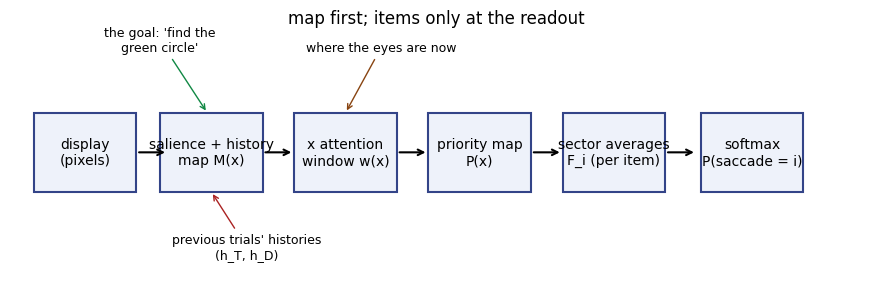

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.03, "display\n(pixels)"),
         (0.19, "salience + history\nmap M(x)"),
         (0.36, "x attention\nwindow w(x)"),
         (0.53, "priority map\nP(x)"),
         (0.70, "sector averages\nF_i (per item)"),
         (0.875, "softmax\nP(saccade = i)")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.13, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.065, 0.51, label, ha="center", va="center", fontsize=10)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.17, 0.51), xytext=(x + 0.13, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'find the\ngreen circle'", xy=(0.25, 0.67),
            xytext=(0.19, 0.92), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previous trials' histories\n(h_T, h_D)", xy=(0.255, 0.35),
            xytext=(0.30, 0.08), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.annotate("where the eyes are now", xy=(0.425, 0.67),
            xytext=(0.47, 0.92), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#884411"))
ax.set_xlim(0, 1.08); ax.set_ylim(0, 1); ax.axis("off")
plt.title("map first; items only at the readout")
plt.show()

## 2. The displays: one example per study

The dataset pools 11 experiments. Every subject searched one fixed
shape all session, so displays are reconstructed in canonical form —
a CIRCLE target among heterogeneous other shapes, green target color,
red singleton (each study's own color pair is shown here for
flavor). The target is defined by its shape and never "pops out" as
the odd one; the color singleton does. (Needs
`dataset/saccades_ctx.csv` from the build steps; Hamblin-Frohman
ships no color labels, so it falls back to green/red.)

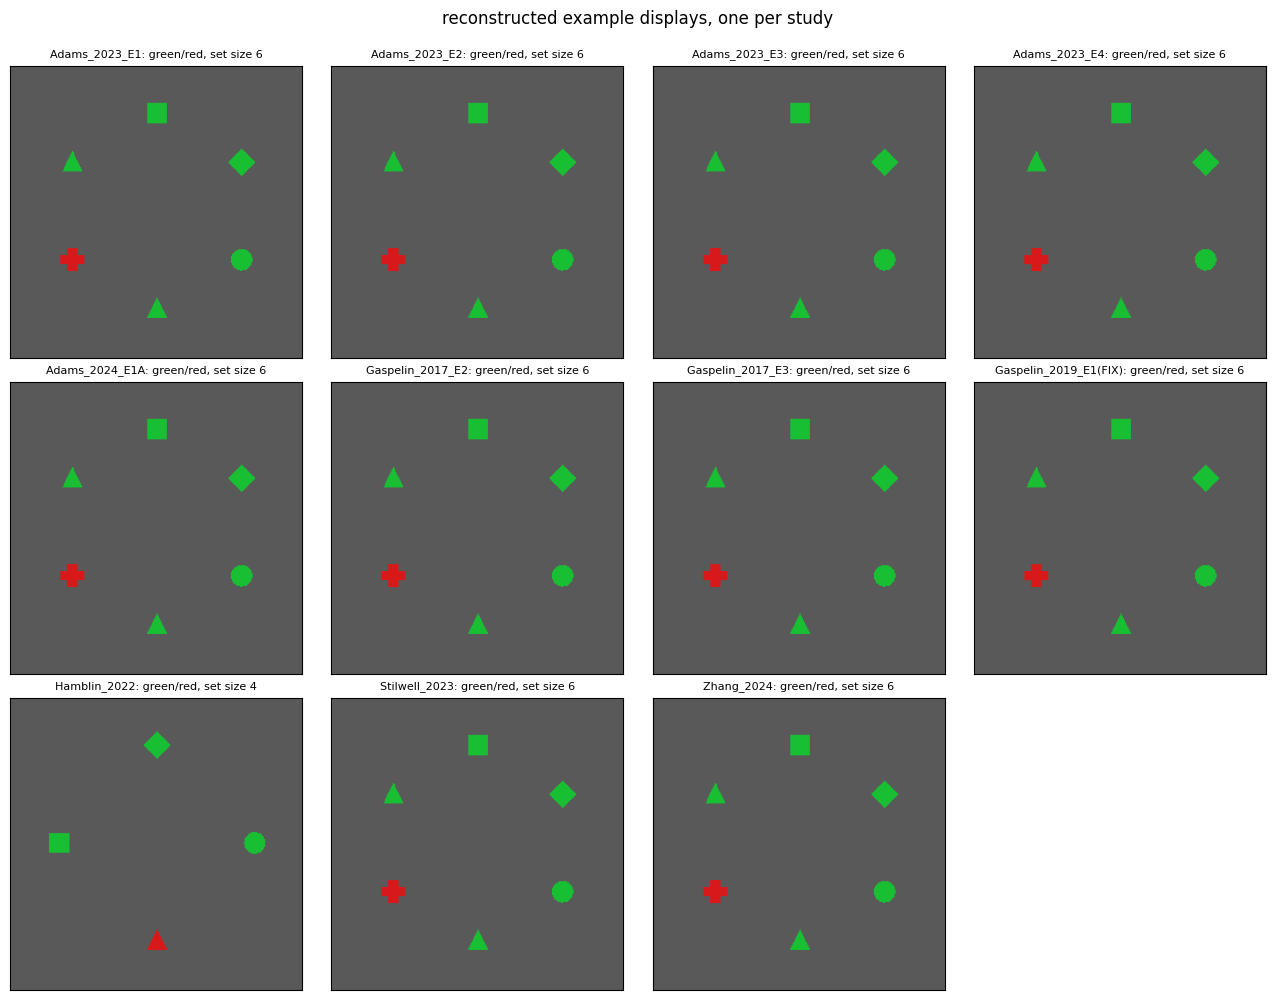

In [3]:
gal = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False,
                  usecols=["study", "setsize", "targCol", "singCol"])
gal = gal[gal.singCol != "none"]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, (study, sub) in zip(axes.flat, gal.groupby("study")):
    setsize = int(sub.setsize.mode()[0])
    tc, sc = sub[["targCol", "singCol"]].mode().iloc[0]
    ipos, _ = item_positions(setsize)
    tg, sg = 2, (2 + setsize // 2) % setsize + 1   # target & singleton slots
    items = [dict(x=ipos[j][0], y=ipos[j][1],
                  color=sc if (j + 1) == sg else tc,
                  shape=shape_for(j + 1, tg)) for j in range(setsize)]
    ax.imshow(render(items), origin="lower")
    ax.set_title(f"{study}: {tc}/{sc}, set size {setsize}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[gal.study.nunique():]:
    ax.axis("off")
plt.suptitle("reconstructed example displays, one per study", y=0.995)
plt.tight_layout()
plt.show()

## 3. From one display to the goal-modified salience map

We take one canonical display and follow it through the perception
stage, one parameter at a time.

**The color pathway.** The raw color contrast map (how much each
pixel's color stands out from the background, signed along the
red-green axis) is split into two RECTIFIED channels:

- `relu(D_T)` — the target-color channel: nonzero only where the
  display matches the target color (the green items). Its gain is
  `g_T`: **pure enhancement**. Higher `g_T` lifts the green items and
  touches nothing else — after rectification the red item's value
  in this channel is exactly zero;
- `relu(D_dist)` — the distractor-color channel: nonzero only where
  the display matches the distractor color (the red singleton). Its
  gain is `g_D`, entering with a minus sign: **pure suppression**.
  Higher `g_D` digs the singleton's hole deeper and touches nothing
  else. (`b = 0` would mean no down-weighting at all; `b < 0` would
  make the distractor color attract — capture. The data choose.)

Because each gain now acts on its own one-sided channel, `g_T` and
`g_D` have separate, readable meanings — this is why the one-sided
form is the model of record (a fully linear form fits the same to
within noise).

The combined color evidence is their sum:

    g_T * relu(D_T)  -  g_D * relu(D_dist)

The gains below are placeholders; §8 learns them from the eye
movements. Every map has its own color bar, and each panel is
scaled to its own maximum — so turning a knob changes only its own
panel, and magnitudes are compared by reading the color bars, not
the color intensity.

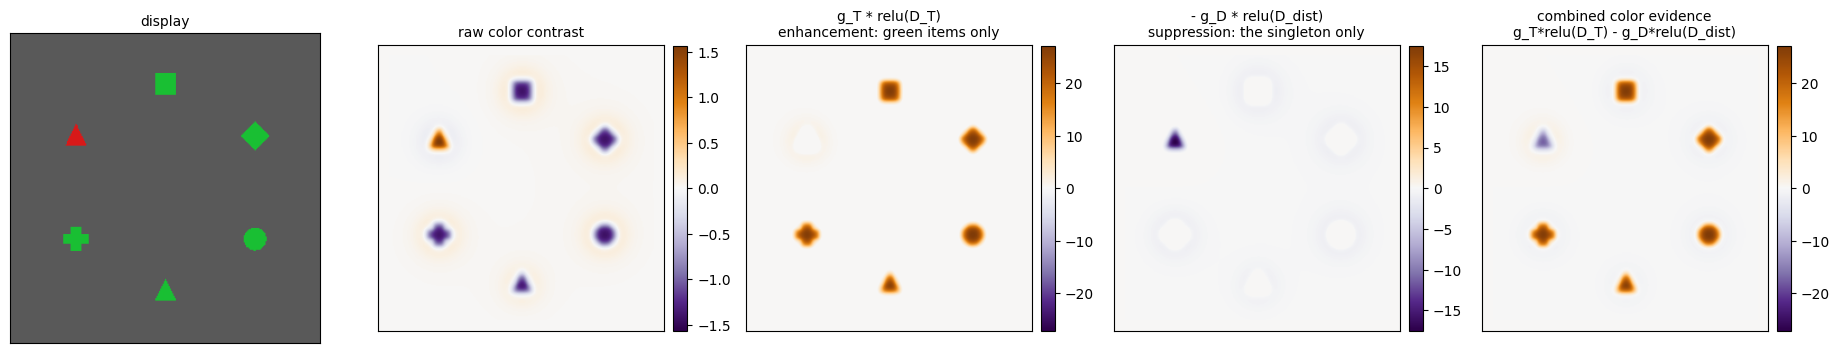

In [4]:
# placeholder gains - arbitrary units; magnitudes picked so the demo
# maps and Sec. 6 probabilities are visibly structured (training
# replaces them with fitted values on standardized evidence)
gT_demo, gD_demo, gF_demo = 18.0, 10.0, 14.0

TARG, SING = 1, 4
items = [dict(x=pos[j][0], y=pos[j][1],
              color="red" if j == SING else "green",
              shape=shape_for(j + 1, TARG + 1)) for j in range(6)]
img = render(items)
maps = opponency_contrast(img)
u = template_axis("green")            # the goal color, as a direction
perp = (-u[1], u[0])

goal_map = u[0]*maps["RG"] + u[1]*maps["BY"]          # D_T: + green, - red
off_map = perp[0]*maps["RG"] + perp[1]*maps["BY"]
uS = template_axis("red")
cphi, sphi = u[0]*uS[0] + u[1]*uS[1], perp[0]*uS[0] + perp[1]*uS[1]
distractor_map = cphi*goal_map + sphi*off_map         # D_dist: + red
chanT = np.maximum(goal_map, 0)                       # relu(D_T)
chanD = np.maximum(distractor_map, 0)                 # relu(D_dist)
color_evidence = gT_demo*chanT - gD_demo*chanD          # combined

fig, axes = plt.subplots(1, 5, figsize=(18.5, 3.8))
axes[0].imshow(img, origin="lower"); axes[0].set_title("display", fontsize=10)
v = np.abs(maps["RG"]).max()
im1 = axes[1].imshow(maps["RG"], origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("raw color contrast", fontsize=10)
v2 = (gT_demo*chanT).max()
im2 = axes[2].imshow(gT_demo*chanT, origin="lower", cmap="PuOr_r",
                     vmin=-v2, vmax=v2)
axes[2].set_title("g_T * relu(D_T)\nenhancement: green items only",
                  fontsize=10)
v3 = (gD_demo*chanD).max()
im3 = axes[3].imshow(-gD_demo*chanD, origin="lower", cmap="PuOr_r",
                     vmin=-v3, vmax=v3)
axes[3].set_title("- g_D * relu(D_dist)\nsuppression: the singleton only",
                  fontsize=10)
v = np.abs(color_evidence).max()
im4 = axes[4].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v, vmax=v)
axes[4].set_title("combined color evidence\ng_T*relu(D_T) - g_D*relu(D_dist)",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes[1:], [im1, im2, im3, im4]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

Read the color pathway left to right: the raw map knows only
that colored things sit on a gray background; the `g_T` panel contains
ONLY the green items (turning `g_T` up rescales this panel alone); the
`g_D` panel contains ONLY the singleton's hole (turning `g_D` up deepens
it alone); their sum is the combined color evidence — green items
up, singleton below zero, each side under its own knob.

**Adding shape.** The shape map is color-blind: how circle-like
each location's contour is, computed from the pixels by template
matching (normalized cross-correlation with a circle, minus the
best competing shape's match). Its gain is `g_F`: higher
`g_F` raises the circle-matching location — the target — over
every other item, green or red. The **goal-modified salience map**
is the pixel-wise sum:

    g_T * relu(D_T) - g_D * relu(D_dist) + g_F * shape

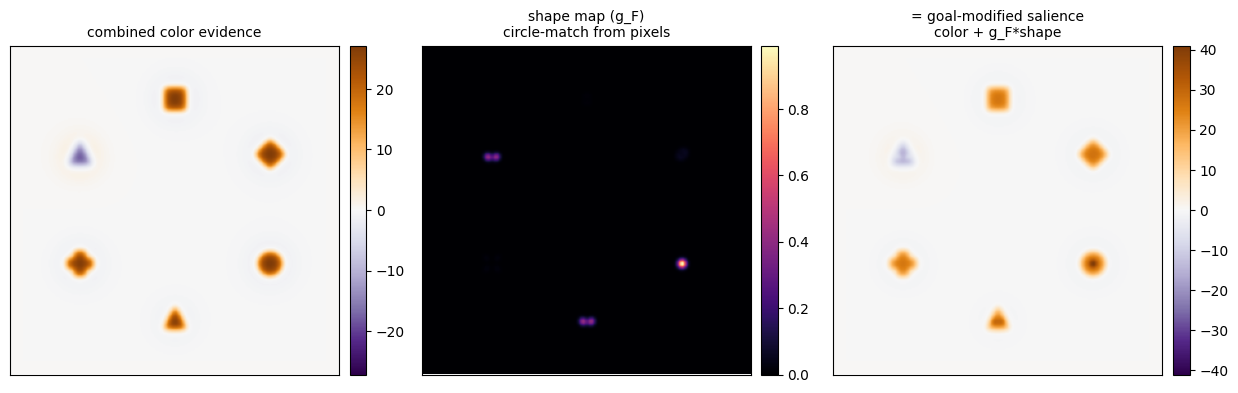

In [5]:
smap = shape_match_map(render(items, scale=2))
smap = smap[::2, ::2] / max(smap.max(), 1e-9)         # display scale
salience = color_evidence + gF_demo * smap

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
v = np.abs(color_evidence).max()
im0 = axes[0].imshow(color_evidence, origin="lower", cmap="PuOr_r",
                     vmin=-v, vmax=v)
axes[0].set_title("combined color evidence", fontsize=10)
im1 = axes[1].imshow(smap, origin="lower", cmap="magma")
axes[1].set_title("shape map (g_F)\ncircle-match from pixels",
                  fontsize=10)
v = np.abs(salience).max()
im2 = axes[2].imshow(salience, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[2].set_title("= goal-modified salience\ncolor + g_F*shape",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in zip(axes, [im0, im1, im2]):
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

In the final map the target is doubly bright (right color AND
right shape), the plain green items carry color evidence only, and
the red singleton is a signed hole whose depth is `g_D`'s alone to
set. Signed maps: orange = positive, purple = negative, scales
symmetric around zero; the shape map is non-negative.

**Two things you may notice in the shape map:**

- **The bright spot is smaller than the circle itself.** That is
  what a template-MATCH map looks like, not a smoothing artifact.
  Each pixel answers "is a circle centered HERE?" — not "is this
  pixel part of a circle?" The answer is a clear yes only when the
  template sits right on the item's center; shift it a few pixels
  and the match drops. So the map shows a narrow alignment peak at
  the circle's center rather than a filled disk — and that is all
  the model needs, because shape evidence is read out exactly at
  the item centers.
- **Faint dots at some non-circle items (the triangles).** The map
  scores each spot as "circle match MINUS the best other shape's
  match," so at a triangle's center the triangle template wins and
  the score is zero. But just OFF a triangle's center the
  comparison tilts the other way: a circle is round, so its
  template forgives a small misalignment, while the triangle
  template loses its match quickly. Those thin rims of
  "circle-beats-triangle-by-a-sliver" survive as faint dots. They
  are the honest fingerprint of computing shape from pixels —
  about 6x weaker than the real circle's peak, so the model is
  never actually fooled. (Color plays no role: the image is reduced
  to black-and-white before shape matching, so the red singleton's
  stronger color cannot masquerade as shape evidence.)

## 4. Location-based selection history

The model remembers WHERE things have been — not what they looked
like. Two memories, one number per screen location, updated after
every trial as **leaky accumulators**:

    h = (1 - eta) * h              # everything leaks a little
    h[location] += eta             # this trial's location gets a boost

`h_T` tracks target locations (update speed `eta_T`), `h_D` tracks
distractor locations (`eta_D`).

**Units:** each location's `h` is a recency-weighted occupancy — the
leaky average of "was the item here this trial?" (1 or 0) — so every
entry lies between 0 and 1 on its own. These are NOT probabilities
and nothing normalizes them across locations. (For `h_T` the six
entries do happen to sum to ~1 at steady state, because exactly one
target appears per trial: the update adds `eta` to one slot while
shrinking all slots by `1 - eta`. For `h_D` the sum settles near
the singleton-present rate instead, since absent trials add
nothing.) A large `eta` means a fast, forgetful
memory dominated by the last trial; a small `eta` means a slow one
that averages many trials. Their gains in the priority map are
`beta_T` (positive: past target locations PULL the eyes) and `beta_D`
(negative: past distractor locations PUSH the eyes away).

Below, in three steps:

1. **the accumulator** (left) — one location's `h` across simulated
   trials, for a fast and a slow `eta`; each tick marks a trial
   where the item landed on that location;
2. **the history VECTOR** (middle) — one number per item location:
   `beta_T*hT_i + beta_D*hD_i`. Past target locations pull
   (positive), past distractor locations push (negative);
3. **the history MAP** (right) — the vector turned into a 2-D map:
   each item's value is placed at its screen location and smoothed
   with a fixed spatial kernel (sigma 0.03, a stated model
   assumption — `paint_slots` below). This map will be ADDED to the
   goal-modified salience map in Sec. 5, so that one attention
   window can gate stimulus and history alike (Sec. 6).

history vector: [ 0.18  2.78  0.18 -0.4   0.18  0.38]


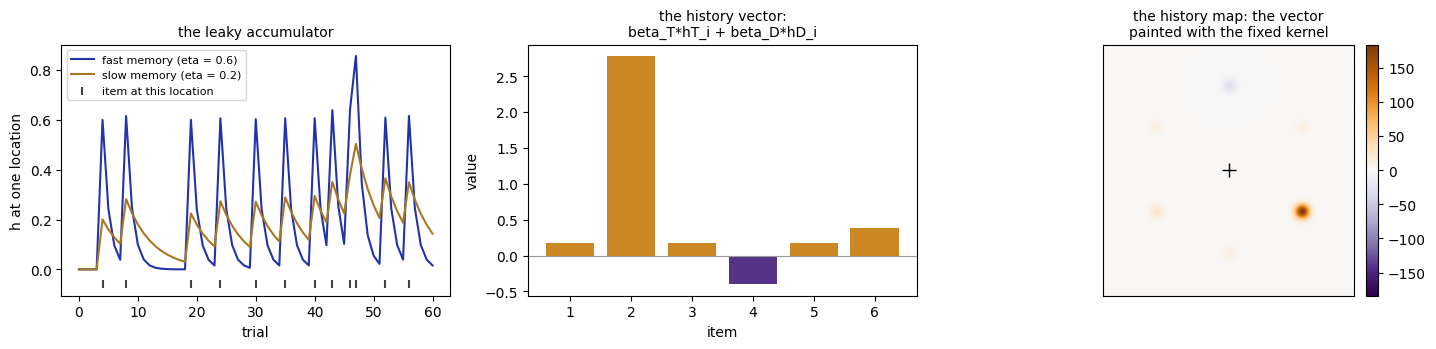

In [6]:
rng = np.random.default_rng(4)
hits = rng.random(60) < 0.3                 # trials landing on this location
h_fast = np.zeros(61); h_slow = np.zeros(61)
for t in range(60):
    h_fast[t+1] = 0.4*h_fast[t] + 0.6*hits[t]     # eta = 0.6
    h_slow[t+1] = 0.8*h_slow[t] + 0.2*hits[t]     # eta = 0.2

cx = cy = IMG / 2
px_per_unit = IMG / 1.5
yy, xx = np.mgrid[0:IMG, 0:IMG]

def paint_slots(vals, sig=0.03):
    # each bump NORMALIZED to unit total weight in its sector (as in
    # training): sig sets how far a bump spreads, not how much it counts
    m = np.zeros((IMG, IMG))
    sector_px = IMG * IMG / 6
    for j in range(6):
        px, py = (pos[j][0]+0.75)/1.5*IMG, (pos[j][1]+0.75)/1.5*IMG
        bump = np.exp(-((xx-px)**2 + (yy-py)**2)
                      / (2*(sig*px_per_unit)**2))
        m += vals[j] * bump * (sector_px / bump.sum())
    return m

# recency-weighted occupancies (see Units above): h_T sums to ~1
# (one target per trial), h_D to ~the singleton-present rate
hT_demo = np.array([0.05, 0.70, 0.05, 0.05, 0.05, 0.10])  # target often at slot 2
hD_demo = np.array([0.02, 0.02, 0.02, 0.60, 0.02, 0.02])  # distractor often at slot 4
betaT_demo, betaD_demo = 4.0, -1.0      # placeholder gains (in the
                                        # normalized-kernel units)

# ---- the history VECTOR: one number per item location ----
hist_vec = betaT_demo*hT_demo + betaD_demo*hD_demo
print("history vector:", hist_vec.round(3))

# ---- the history MAP: the vector painted with the fixed kernel ----
history_map = paint_slots(hist_vec)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(h_fast, color="#2233aa", label="fast memory (eta = 0.6)")
axes[0].plot(h_slow, color="#aa7722", label="slow memory (eta = 0.2)")
axes[0].scatter(np.where(hits)[0]+1, np.full(hits.sum(), -0.06),
                marker="|", color="#444444", label="item at this location")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("h at one location")
axes[0].set_title("the leaky accumulator", fontsize=10)
axes[0].legend(fontsize=8)
cols = ["#cc8822" if v_ >= 0 else "#553388" for v_ in hist_vec]
axes[1].bar(range(1, 7), hist_vec, color=cols)
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel("item"); axes[1].set_ylabel("value")
axes[1].set_title("the history vector:\n"
                  "beta_T*hT_i + beta_D*hD_i", fontsize=10)
v = np.abs(history_map).max()
im_p = axes[2].imshow(history_map, origin="lower", cmap="PuOr_r",
                      vmin=-v, vmax=v)
axes[2].plot(IMG/2, IMG/2, "k+", ms=10)
axes[2].set_title("the history map: the vector\n"
                  "painted with the fixed kernel", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im_p, ax=axes[2], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 5. Combining stimulus and history into one map

The pre-window priority map is a pixel-by-pixel SUM: the
goal-modified salience map of Sec. 3 plus the history map of
Sec. 4. Stimulus evidence and selection history now live in the
same 2-D object — which is what lets a single attention window
gate both at once in Sec. 6.

    combined(x) = salience(x) + history_map(x)

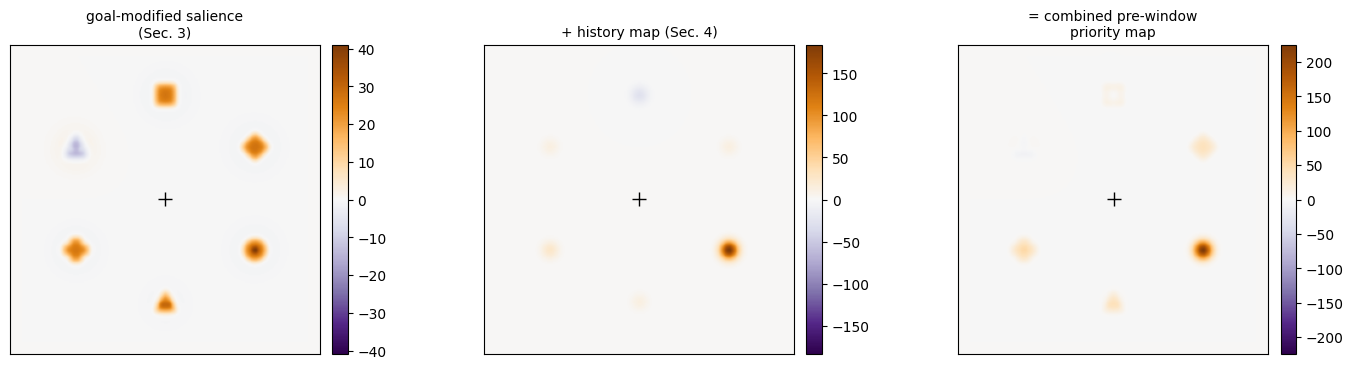

In [7]:
combined = salience + history_map      # the pre-window priority map

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.8))
for ax, m, ttl in [(axes[0], salience, "goal-modified salience\n(Sec. 3)"),
                   (axes[1], history_map, "+ history map (Sec. 4)"),
                   (axes[2], combined, "= combined pre-window\npriority map")]:
    v = max(np.abs(m).max(), 1e-9)
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(IMG/2, IMG/2, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 6. The attention window

The window is an **ego-anchored sigmoid of distance from the eyes**:

    window(d) = sigmoid( k * (r0 - d) )

Here `d` is the distance between the current fixation (where the
eyes are) and a location on the screen — for the 2-D map, every
pixel gets its own `d`; for the item readout, `d` is the
fixation-to-item distance. Distances are in display units where
the ring items sit at `d = 0.5` from the screen center.

Two parameters shape the window: `r0` is its REACH (the distance
at which weight has fallen to one half — a location closer than
`r0` gets most of the weight, one farther gets little) and `k` its
STEEPNESS (how abruptly weight falls off around `r0`). Left: the 1-D function. Middle: the same function
painted over the display as a 2-D field centered on fixation.
Right: the FINAL priority map — the window multiplies the combined
pre-window map of Sec. 5, pixel by pixel:

    priority(x) = window(x) * combined(x)

To choose between items, the priority map is AVERAGED over each
item's SECTOR — one number per item (an average, so the number does
not depend on how big the sector is). A sector is the pie slice of
the display belonging to one item: all pixels whose direction from
fixation is within 30 degrees of the direction to that item. With
six evenly spaced items the six sectors tile the display like a pie
cut into six slices, one item per slice — dashed lines in the
middle panel below. Everything in an item's slice, near or far,
counts toward that item's number; the window decides how much the
near versus far parts weigh.

Why collapse a whole map into six numbers at all? Not for speed —
because the behavior we predict is a six-way CHOICE. The data
record which item each first saccade landed on, so the softmax
needs exactly one value per item; the map stays a map through
every earlier stage and is condensed only here, at the readout.
(Keeping the full map and predicting landing COORDINATES instead
is a real extension — the raw data contain them — but the item
choice is what this literature, and this model, score.) (The trained pipeline computes
the same product along rays toward each item instead of every
pixel — faster, same math.)

**Why changing `r0` on its own can look like nothing happened:**
from central fixation every ring item sits at the same distance
(d = 0.5), so the window multiplies the whole visible map by ONE
number — and a panel normalized to its own maximum cancels a
uniform rescaling. To make the window's effect visible, the last
two panels show the SAME combined map under two different windows —
a wide one and a narrow one — drawn on the SAME color scale: the
narrow window dims the entire map uniformly. That uniform dimming
is the §1 note made visible: within this model's first-saccade
scope the window acts as a shared gain on equidistant items, which
is exactly why the data constrain its parameters only weakly and
it is kept on theoretical definition.

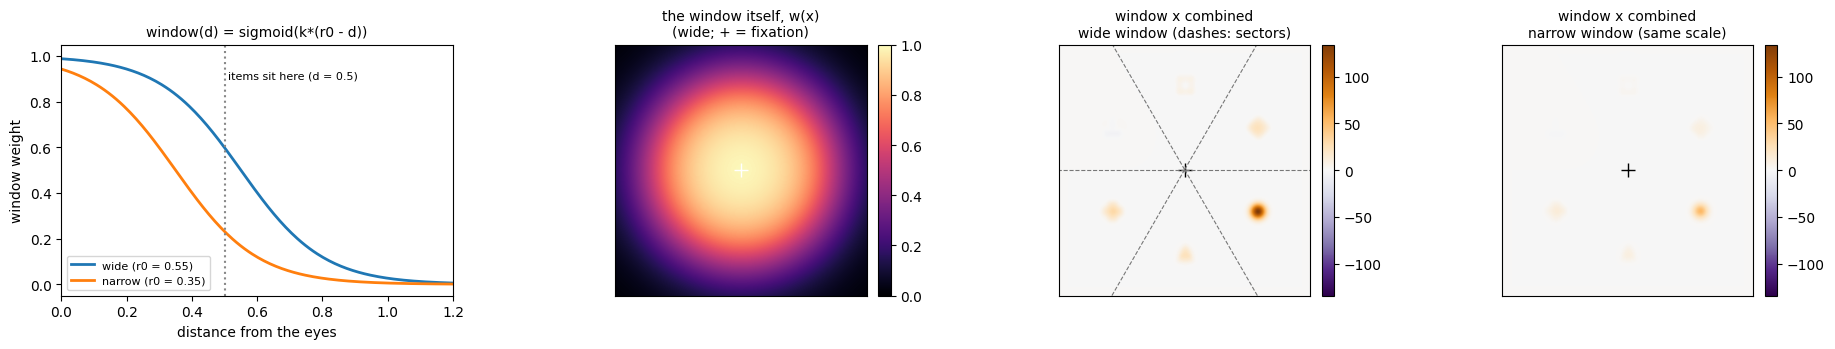

In [8]:
k_demo, r0_demo = 8.0, 0.55               # a WIDE window
r0_narrow = 0.35                            # and a NARROW one

d = np.linspace(0, 1.2, 200)
cx = cy = IMG / 2
px_per_unit = IMG / 1.5
yy, xx = np.mgrid[0:IMG, 0:IMG]
dist_map = np.hypot(xx - cx, yy - cy) / px_per_unit
window_map = sigmoid(k_demo * (r0_demo - dist_map))     # the wide window
priority_wide = window_map * combined
priority_narrow = sigmoid(k_demo * (r0_narrow - dist_map)) * combined

fig, axes = plt.subplots(1, 4, figsize=(18.5, 3.6))
axes[0].plot(d, sigmoid(k_demo * (r0_demo - d)), lw=2,
             label=f"wide (r0 = {r0_demo})")
axes[0].plot(d, sigmoid(k_demo * (r0_narrow - d)), lw=2,
             label=f"narrow (r0 = {r0_narrow})")
axes[0].axvline(0.5, color="#888888", ls=":")
axes[0].text(0.51, 0.9, "items sit here (d = 0.5)", fontsize=8,
             clip_on=True)
axes[0].set_xlim(0, 1.2); axes[0].set_ylim(-0.05, 1.05)
axes[0].set_xlabel("distance from the eyes")
axes[0].set_ylabel("window weight")
axes[0].set_title("window(d) = sigmoid(k*(r0 - d))", fontsize=10)
axes[0].legend(fontsize=8)

imw = axes[1].imshow(window_map, origin="lower", cmap="magma",
                     vmin=0, vmax=1)
axes[1].plot(cx, cy, "w+", ms=10)
axes[1].set_title("the window itself, w(x)\n(wide; + = fixation)",
                  fontsize=10)
axes[1].set_xticks([]); axes[1].set_yticks([])
fig.colorbar(imw, ax=axes[1], fraction=0.046, pad=0.03)

v = np.abs(priority_wide).max()             # ONE shared color scale
for ax, m, ttl in [(axes[2], priority_wide,
                    "window x combined\nwide window (dashes: sectors)"),
                   (axes[3], priority_narrow,
                    "window x combined\nnarrow window (same scale)")]:
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(cx, cy, "k+", ms=10)
    if m is priority_wide:                  # sector boundaries: six pie slices
        for jj in range(6):
            ab = np.arctan2(pos[jj][1], pos[jj][0]) + np.pi/6
            ax.plot([cx, cx + IMG*np.cos(ab)], [cy, cy + IMG*np.sin(ab)],
                    ls="--", lw=0.8, color="#777777")
        ax.set_xlim(0, IMG-1); ax.set_ylim(0, IMG-1)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()

## 7. The final model, in three small functions

Everything above, assembled — and nothing new. Each function is one
section of this notebook:

1. **`combined_map`** (Secs. 3 + 4): the goal-modified salience map
   (color gains + `g_F`*shape, pixel by pixel) PLUS the history
   field (`beta_T*h_T + beta_D*h_D` painted at the item locations, Sec. 4).
   This is the priority map BEFORE attention;
2. **`priority_map`** (Sec. 6): the attention window multiplies that
   one combined map, pixel by pixel — `window * (salience +
   history)`. Because the window multiplies the SUM, it gates
   color, shape, and history alike (Sec. 5 built exactly this sum);
3. **`predict_saccade`** (Sec. 6 readout): average the priority map
   over each item's sector — six numbers — and softmax them into
   the predicted probability of the first saccade.

The worked example below shows the map before and after the window,
then the six priorities and the prediction.

(All nine Sec. 1 parameters now act inside these functions:
the etas run the accumulators over the raw past-trial
locations, the betas weigh the result, the g's and k, r0 do
their Sec. 3 and Sec. 6 jobs.)

In [9]:
def accumulate_history(past_locs, eta):
    '''Sec. 4's leaky accumulator, replayed over past trials.
    past_locs: where the item appeared on each previous trial
    (1-6; 0 = absent), oldest first. After each trial everything
    fades by (1 - eta) and that trial's location gets an eta boost.'''
    h = np.zeros(6)
    for loc in past_locs:
        h = (1 - eta) * h
        if loc:
            h[int(loc) - 1] += eta
    return h


def combined_map(img, past_targets, past_singletons,
                 g_T, g_D, g_F, beta_T, beta_D, eta_T, eta_D,
                 target_color="green", distractor_color="red"):
    '''The pre-window priority map M(x) of Sec. 1, from raw inputs:
    the display image plus the RAW TRIAL HISTORY - the lists of
    where the target and the singleton appeared on previous trials.

    All of Sec. 1's history parameters act here: eta_T, eta_D run
    the Sec. 4 accumulators over the past (how the past is
    compressed into h_T, h_D), and beta_T, beta_D weigh the result
    in the map.'''
    cmaps = opponency_contrast(img)                      # Sec. 3, line for line
    u_ = template_axis(target_color); perp_ = (-u_[1], u_[0])
    gmap = u_[0]*cmaps["RG"] + u_[1]*cmaps["BY"]
    omap = perp_[0]*cmaps["RG"] + perp_[1]*cmaps["BY"]
    uS_ = template_axis(distractor_color)
    cph_ = u_[0]*uS_[0] + u_[1]*uS_[1]
    sph_ = perp_[0]*uS_[0] + perp_[1]*uS_[1]
    dmap = cph_*gmap + sph_*omap
    chT = np.maximum(gmap, 0)                            # relu(D_T)
    chD = np.maximum(dmap, 0)                            # relu(D_dist)
    sm = shape_match_map(img); sm = sm / max(sm.max(), 1e-9)
    salience = g_T*chT - g_D*chD + g_F*sm                # Sec. 3
    h_T = accumulate_history(past_targets, eta_T)        # Sec. 4
    h_D = accumulate_history(past_singletons, eta_D)
    history_field = paint_slots(beta_T*h_T + beta_D*h_D)
    return salience + history_field


def priority_map(img, past_targets, past_singletons,
                 g_T, g_D, g_F, k, r0, beta_T, beta_D, eta_T, eta_D):
    '''The final priority map P(x) = w(x) * M(x) (Sec. 1, steps 1-2).
    k and r0 are the window's steepness and reach (Sec. 6).'''
    yy_, xx_ = np.mgrid[0:IMG, 0:IMG]
    d_px = np.hypot(xx_ - IMG/2, yy_ - IMG/2) / (IMG/1.5)
    window = sigmoid(k * (r0 - d_px))                    # Sec. 6
    return window * combined_map(img, past_targets, past_singletons,
                                 g_T, g_D, g_F, beta_T, beta_D,
                                 eta_T, eta_D)


def predict_saccade(pm):
    '''Takes the OUTPUT of priority_map() - the 2-D priority map -
    averages it over each item's sector (F_i), and softmaxes the six
    averages into P(first saccade = i) (Sec. 1, steps 3-4).'''
    yy_, xx_ = np.mgrid[0:IMG, 0:IMG]
    ang = np.arctan2(yy_ - IMG/2, xx_ - IMG/2)
    priorities = np.zeros(6)
    for j_ in range(6):
        aj = np.arctan2(pos[j_][1], pos[j_][0])
        in_sector = np.abs((ang - aj + np.pi) % (2*np.pi) - np.pi) < np.deg2rad(30)
        priorities[j_] = pm[in_sector].mean()
    F_ = torch.tensor(priorities).float()[None]
    return torch.softmax(F_, 1), F_

print("the model: combined_map -> priority_map -> predict_saccade")

the model: combined_map -> priority_map -> predict_saccade


### One worked example, raw image to prediction

Inputs: the Sec. 3 display (pixels), the Sec. 4 histories, and
placeholder weights. The two map panels are the same priority map
before and after the attention window, on one shared color scale.
(With these placeholder gains the history bump at item 2 dominates;
the trained gains of Sec. 7 set the real balance.)

h_T built inside: [0.   0.71 0.04 0.24 0.   0.01]
h_D built inside: [0.05 0.   0.   0.7  0.   0.  ]
priority per item: [ 0.13  1.87  0.32  0.52 -0.05  0.26]
P(first saccade):  [ 8.9 50.1 10.6 13.   7.4 10. ] %
most likely saccade: item 2 (the target; one PREDICTED saccade = one draw from these)


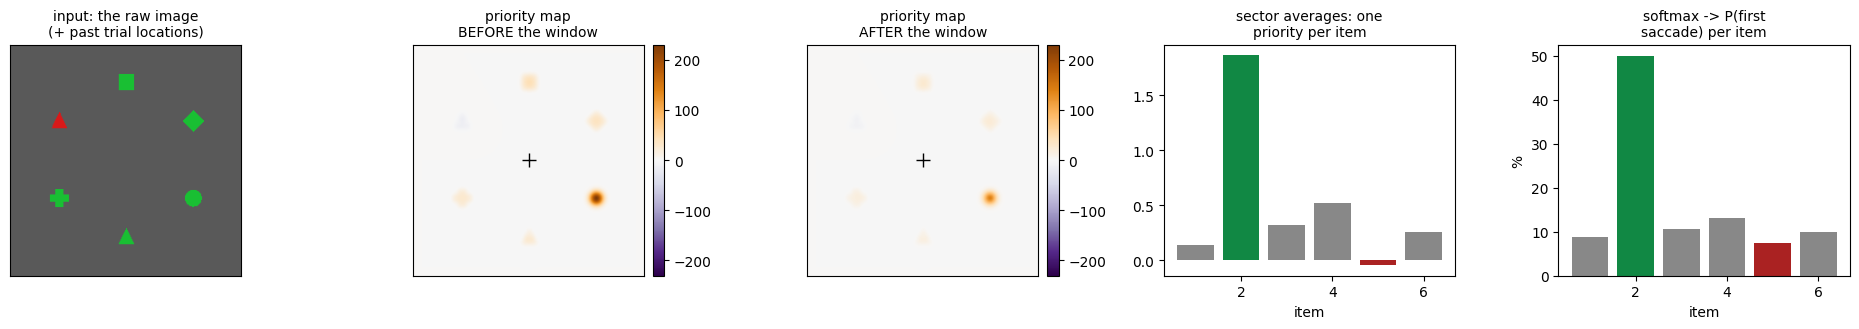

In [10]:
# the nine Sec. 1 parameters, in one place
PARAMS = dict(g_T=gT_demo, g_D=gD_demo, g_F=gF_demo,
              k=k_demo, r0=r0_demo,
              beta_T=betaT_demo, beta_D=betaD_demo,
              eta_T=0.6, eta_D=0.2)          # the Sec. 4 demo speeds

# raw trial history: where things appeared on previous trials
past_targets    = [2, 5, 2, 2, 6, 2, 3, 2, 4, 2]   # target favored loc 2
past_singletons = [4, 4, 0, 1, 4, 4, 0, 4, 4, 4]   # singleton favored loc 4
print("h_T built inside:", accumulate_history(past_targets, 0.6).round(2))
print("h_D built inside:", accumulate_history(past_singletons, 0.2).round(2))

MAP_PARAMS = {k_: v for k_, v in PARAMS.items() if k_ not in ("k", "r0")}
before = combined_map(img, past_targets, past_singletons, **MAP_PARAMS)
after = priority_map(img, past_targets, past_singletons, **PARAMS)
p_ex, F_ex = predict_saccade(after)   # the priority map from above

print("priority per item:", F_ex[0].numpy().round(2))
print("P(first saccade): ", (p_ex[0].numpy() * 100).round(1), "%")
print("most likely saccade: item", int(F_ex[0].argmax()) + 1,
      "(the target; one PREDICTED saccade = one draw from these)")

fig, axes = plt.subplots(1, 5, figsize=(19, 3.4))
axes[0].imshow(img, origin="lower")
axes[0].set_title("input: the raw image\n(+ past trial locations)", fontsize=10)
v = np.abs(before).max()                    # ONE scale for before/after
for ax, m, ttl in [(axes[1], before, "priority map\nBEFORE the window"),
                   (axes[2], after, "priority map\nAFTER the window")]:
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(IMG/2, IMG/2, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
for ax in axes[:3]:
    ax.set_xticks([]); ax.set_yticks([])
cols = ["#888888"] * 6
cols[TARG], cols[SING] = "#118844", "#aa2222"
axes[3].bar(range(1, 7), F_ex[0].numpy(), color=cols)
axes[3].set_title("sector averages: one\npriority per item", fontsize=10)
axes[3].set_xlabel("item")
axes[4].bar(range(1, 7), p_ex[0].numpy() * 100, color=cols)
axes[4].set_title("softmax -> P(first\nsaccade) per item", fontsize=10)
axes[4].set_xlabel("item"); axes[4].set_ylabel("%")
plt.tight_layout()
plt.show()

## 8. Train on the actual data

The dataset holds every first saccade from 333 people: which item
they looked at first, the display they saw, and the full trial order
(needed to rebuild each person's memories).

**What is excluded, from both training and test data** (the
exclusions happen at the pooling step, `pool_data.py`):

- trials with **motion/dynamic or onset singletons** (abrupt onsets,
  singleton onsets, motion singletons) — only static color-singleton
  and singleton-absent trials are analyzed, as in the source paper;
- **Stilwell's low-salience singleton trials** — the canonical
  reconstruction (a salient red-on-green singleton) only matches the
  high-salience displays; the low-salience condition is held
  entirely outside the model and used as an out-of-sample test in §10.

We hold out 20% of the *people* — the model never sees them during
training — and fit by maximum likelihood: replay everyone's trials,
score the probability the model gives to each real eye movement, and
nudge all nine numbers by gradient descent. The memory speeds are
learned too, so the memories are rebuilt inside the training loop.

One practical note: training runs the SAME construction as Sec. 7
— pre-window map, window, sector average — but does not re-render
pixels at every step. Everything before the gains has no learned
weights, so `build_contexts.py` precomputed each display's maps as
sector x DISTANCE-BIN area averages (24 bins per sector; summing
`window(bin) * contribution` over bins IS the sector average of
window x map), and the history field's fixed smoothing kernel
reduces to a precomputed geometry matrix `HM` with `HM @ h` giving
each history's binned field. `combine_evidence()` below is Sec. 7's
model on that cached, binned evidence.

In [11]:
import data

sacc = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False)  # a row per first saccade
ev = pd.read_csv("dataset/events.csv", low_memory=False)  # a row per trial (histories)
ctx = np.load("dataset/contexts_v21.npz")  # precomputed binned maps per display
sacc, tt = data.build_tensors(sacc, ev)    # a few minutes: aligns everything into tensors

from model import color_angles

# look up each saccade's display in the precomputed binned maps (Sec. 7's
# pre-window map, as sector x distance-bin area averages)
cid = torch.tensor(sacc.ctx.values.astype(int))  # which display this saccade saw
P = torch.tensor(ctx["P"])[cid]        # binned color contributions [N, 6, 24, 3]
FP = torch.tensor(ctx["FORMP"])[cid]   # binned shape contributions [N, 6, 24]
HM6 = torch.tensor(ctx["HM6"])         # history-kernel geometry, set size 6
HM4 = torch.tensor(ctx["HM4"])         # ... and set size 4
m6 = torch.tensor((sacc.setsize == 6).values)
cphi, sphi = color_angles(sacc)   # each study's distractor-color axis vs target axis
D_T = P[..., 0]                                          # target-color channel
D_dist = (cphi[:, None, None] * P[..., 0]                # rotate onto the
          + sphi[:, None, None] * P[..., 1])             # distractor axis
radii = torch.linspace(0.09, 1.1, P.shape[2])            # distance bins
N = len(sacc)

def history_profiles(h):
    # each saccade's binned history field: HM @ h (the painted field,
    # precomputed as geometry)
    out = torch.zeros(h.shape[0], 6, P.shape[2])
    out[m6] = torch.einsum("ijd,nj->nid", HM6, h[m6])
    out[~m6] = torch.einsum("ijd,nj->nid", HM4, h[~m6])
    return out

n_subj = tt["eT"].shape[0]
rng = np.random.default_rng(0)
test_subj = torch.zeros(n_subj, dtype=torch.bool)
test_subj[rng.choice(n_subj, n_subj // 5, replace=False)] = True
test = test_subj[tt["si"]]
train = ~test
print(f"{N} saccades; {int((~test_subj).sum())} people to train on, "
      f"{int(test_subj.sum())} held out")

114232 saccades; 267 people to train on, 66 held out


epoch 0: loss 2.7335


epoch 25: loss 1.5582


epoch 50: loss 1.4482


epoch 75: loss 1.4231


epoch 100: loss 1.4194


...

epoch 375: loss 1.4102


epoch 400: loss 1.4102


epoch 425: loss 1.4102


epoch 450: loss 1.4102


epoch 475: loss 1.4102


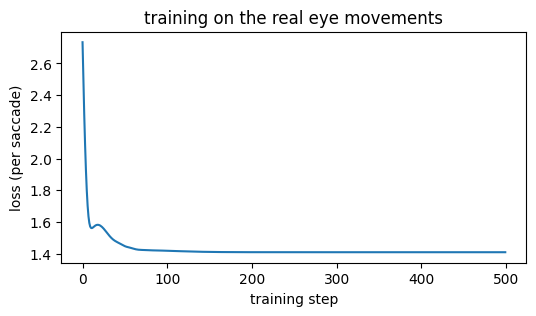

In [12]:
def combine_evidence(D_T, D_dist, FP, HTP, HDP, w, radii):
    # Sec. 7's model on the cached, binned evidence: pre-window map
    # (color + shape + history), window per bin, summed = sector avg
    pre_window = (w["g_T"] * torch.relu(D_T)      # pure enhancement
                  - w["g_D"] * torch.relu(D_dist) # pure suppression
                  + w["g_F"] * FP                 # shape map
                  + w["beta_T"]*HTP + w["beta_D"]*HDP)  # history fields
    window = torch.sigmoid(w["k"] * (w["r0"] - radii))
    return (pre_window * window).sum(-1)

def build_memories(eta_T, eta_D):
    # replay every subject's trials in order; return memory AS OF each trial
    S_, T_, _ = tt["eT"].shape
    hT = torch.zeros(S_, 6); hD = torch.zeros(S_, 6)
    outT, outD = [], []
    for t in range(T_):
        outT.append(hT); outD.append(hD)
        hT = (1 - eta_T) * hT + eta_T * tt["eT"][:, t]
        hD = (1 - eta_D) * hD + eta_D * tt["eD"][:, t]
    return torch.stack(outT, 1), torch.stack(outD, 1)

w = {name: torch.tensor(v, requires_grad=True) for name, v in
     [("g_T", 0.5), ("g_D", 0.3), ("g_F", 1.0),
      ("k", 2.0), ("r0", 0.5), ("beta_T", 0.5), ("beta_D", -0.1)]}
raw_eta = {n: torch.tensor(0.0, requires_grad=True) for n in ["T", "D"]}
optimizer = torch.optim.Adam(list(w.values()) + list(raw_eta.values()),
                             lr=0.05)

losses = []
for epoch in range(500):                       # ~25 minutes
    eta_T = torch.sigmoid(raw_eta["T"]); eta_D = torch.sigmoid(raw_eta["D"])
    memT, memD = build_memories(eta_T, eta_D)
    hT = memT[tt["si"], tt["ti"]]; hD = memD[tt["si"], tt["ti"]]
    F = combine_evidence(D_T, D_dist, FP, history_profiles(hT),
                         history_profiles(hD), w, radii)  # priority per item
    F = F.masked_fill(~tt["valid"], -1e9)     # empty slots can never be chosen
    logp = torch.log_softmax(F, 1).gather(     # softmax -> P(item); keep the
        1, tt["choice"][:, None]).squeeze(1)   # probability of the REAL choice
    loss = -logp[train].mean()                 # maximize likelihood of real saccades
    optimizer.zero_grad(); loss.backward(); optimizer.step()  # nudge the 9 weights
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}")

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("loss (per saccade)")
plt.title("training on the real eye movements")
plt.show()

In [13]:
learned = {k: v.item() for k, v in w.items()}
learned["eta_T"] = torch.sigmoid(raw_eta["T"]).item()
learned["eta_D"] = torch.sigmoid(raw_eta["D"]).item()
for name, meaning in [
        ("g_T", "enhance the target color"),
        ("g_D", "suppress the distractor color"),
        ("g_F", "goal shape attracts"),
        ("k", "window steepness"), ("r0", "window reach"),
        ("beta_T", "pull toward past target locations"),
        ("beta_D", "push from past distractor locations"),
        ("eta_T", "target memory speed (fast)"),
        ("eta_D", "distractor memory speed (slow)")]:
    print(f"{name:8} = {learned[name]:+7.3f}   {meaning}")
print("\nnote: within a two-color display only the a/b COMBINATION is")
print("identified, so their individual signs should not be interpreted.")

g_T      =  +0.298   enhance the target color
g_D      =  -0.024   suppress the distractor color
g_F      =  +0.283   goal shape attracts
k        =  +0.706   window steepness
r0       =  +0.290   window reach
beta_T   =  +4.615   pull toward past target locations
beta_D   =  -1.064   push from past distractor locations
eta_T    =  +0.596   target memory speed (fast)
eta_D    =  +0.146   distractor memory speed (slow)

note: within a two-color display only the a/b COMBINATION is
identified, so their individual signs should not be interpreted.


## 9. Evaluation: how good is it? (held-out people only)

We score the model ONLY on the people it never saw. Three measures,
each with its recipe:

- **Mean probability on the true choice.** For every held-out
  saccade, read off the probability the model assigned to the item
  the person actually looked at, then average the *log* of those
  probabilities and exponentiate (the geometric mean — the standard
  likelihood-based average). Chance is 1/(number of items on
  screen), about 18% across the pooled set sizes.
- **Top-1 accuracy.** How often the person's actual choice was the
  model's single highest-probability item. Chance ~18% again.
- **Pseudo-R-squared.** `1 - NLL_model / NLL_chance`, where NLL is
  the mean negative log-likelihood per saccade and the chance model
  spreads probability evenly over the items. 0 means no better than
  guessing, 1 means perfect prediction; for models of human choices,
  0.2-0.4 counts as excellent (human choices are intrinsically
  variable — even the same person, same display, same history does
  not always look at the same item, so 1.0 is unreachable in
  principle).

In [14]:
with torch.no_grad():
    eta_T = torch.sigmoid(raw_eta["T"]); eta_D = torch.sigmoid(raw_eta["D"])
    memT, memD = build_memories(eta_T, eta_D)
    hT = memT[tt["si"], tt["ti"]]; hD = memD[tt["si"], tt["ti"]]
    F = combine_evidence(D_T, D_dist, FP, history_profiles(hT),
                         history_profiles(hD), w, radii)
    F = F.masked_fill(~tt["valid"], -1e9)
    prob = torch.softmax(F, 1)
    p_true = prob.gather(1, tt["choice"][:, None]).squeeze(1)

nll = -p_true[test].log().mean()
chance = torch.log(tt["valid"].sum(1).float())[test].mean()
print(f"held-out saccades: {int(test.sum())}")
print(f"mean probability on the true choice: "
      f"{p_true[test].log().mean().exp()*100:.1f}%  "
      f"(chance {torch.exp(-chance)*100:.1f}%)")
print(f"top-1 accuracy: "
      f"{(prob.argmax(1) == tt['choice'])[test].float().mean()*100:.1f}%")
print(f"pseudo-R-squared vs chance: {1 - nll/chance:.3f}")

held-out saccades: 23216
mean probability on the true choice: 25.5%  (chance 17.4%)
top-1 accuracy: 46.8%
pseudo-R-squared vs chance: 0.219


**Interpretation.** The model roughly halves the uncertainty about
where a stranger's first saccade will land: about 24% geometric-mean
probability on the true choice against 18% chance, the right item as
its top guess almost half the time against ~18% chance, and a
pseudo-R-squared around 0.2 — squarely in the "excellent for human
choice data" band. For calibration: memorization benchmarks built
from the training people (a lookup table of choice frequencies per
display, even per PERSON) score WORSE than this model, because the
graded history traces carry information no frequency table can
(see RESULTS.md, "Oracle benchmarks").

## 10. Does it behave like people? Three signature patterns

Numbers are one thing; the literature's signature patterns are the
real test. Everything below uses held-out people only, and nothing
was fitted to these specific patterns — they come out of the one
trained equation.

**10a. Oculomotor suppression.** First saccades go to the salient red
distractor LESS often than to an average plain item — the
below-baseline suppression effect this dataset exists to measure.

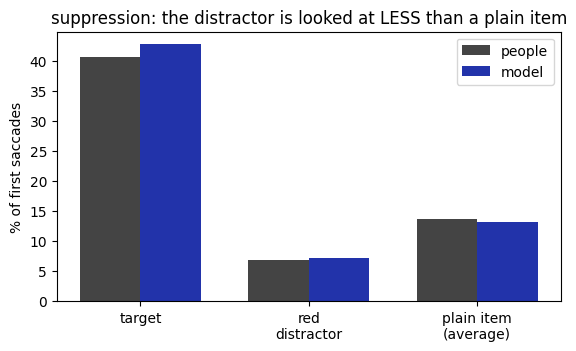

In [15]:
first = torch.tensor((sacc.saccindex == 1).values)  # all True: the scope
sing_present = torch.tensor((sacc.singLoc > 0).values)
rows = torch.arange(N)
isT = torch.zeros(N, 6); isT[rows, torch.tensor(sacc.targLoc.values) - 1] = 1
isS = torch.zeros(N, 6)
sp = torch.tensor(sacc.singLoc.values)
isS[rows[sp > 0], sp[sp > 0] - 1] = 1
chose = torch.zeros(N, 6); chose[rows, tt["choice"]] = 1

m = test & first & sing_present
ot = (chose[m] * isT[m]).sum() / m.sum() * 100
os_ = (chose[m] * isS[m]).sum() / m.sum() * 100
mt = (prob[m] * isT[m]).sum() / m.sum() * 100
ms = (prob[m] * isS[m]).sum() / m.sum() * 100
n_plain = (tt["valid"][m].sum(1).float() - 2).clamp(min=1).mean()
ons = (100 - ot - os_) / n_plain
mns = (100 - mt - ms) / n_plain

x = np.arange(3); width = 0.36
plt.figure(figsize=(6.5, 3.5))
plt.bar(x - width/2, [ot, os_, ons], width, label="people", color="#444444")
plt.bar(x + width/2, [mt, ms, mns], width, label="model", color="#2233aa")
plt.xticks(x, ["target", "red\ndistractor", "plain item\n(average)"])
plt.ylabel("% of first saccades")
plt.title("suppression: the distractor is looked at LESS than a plain item")
plt.legend()
plt.show()

**10b. High- vs low-salience suppression (Stilwell).** Stilwell
(2023) varied how salient the singleton was (its color distance from
the other items) and found MORE suppression for MORE salient
singletons. This is a strong test here: the low-salience trials were
excluded from our dataset entirely (§8), so the model has never seen
them — colors or choices. We apply the trained weights, unchanged,
to Stilwell's displays rendered with their TRUE colors and compare
against the observed rates from the raw data.

(Light version: one target location with the five singleton
positions per color pair, no history terms — they balance across
conditions. The full battery is `stilwell_salience.py`. Observed
rates below come from the raw Stilwell file, which is not in the
repo — they are quoted from that battery.)

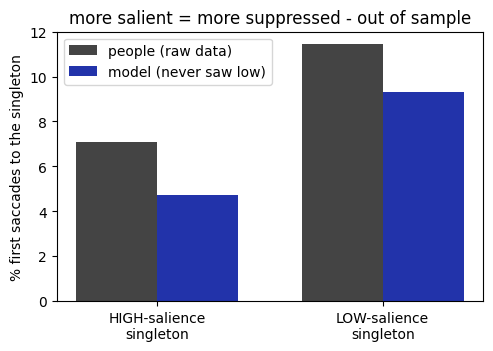

       obs  mod
high   7.1  4.7
low   11.4  9.3


In [16]:
# (salience condition, target color, singleton color, n, observed sing %)
PAIRS = [("high", "blue", "red",  2158,  7.0),
         ("low",  "blue", "teal", 2157, 11.0),
         ("high", "pink", "blue", 2160,  7.6),
         ("low",  "pink", "red",  2153,  9.3),
         ("high", "red",  "blue", 2159,  8.1),
         ("low",  "red",  "pink", 2160, 14.8),
         ("high", "teal", "pink", 1887,  5.4),
         ("low",  "teal", "blue", 1889, 10.5)]

# normalization constants of the canonical training build (same
# display_evidence the pipeline uses)
canon = [display_evidence(6, 1, sl, "green", "red") for sl in range(2, 7)]
canon += [display_evidence(6, 1, 0, "green", "none")]
P_STD = np.abs(np.stack([c[0] for c in canon])[..., :2]).std()
F_STD = np.stack([c[1] for c in canon]).std()
ZH = torch.zeros(1, 6, NBINS)      # zero histories (they balance)

def model_sing_rate(tc, sc_):
    uT, uS2 = template_axis(tc), template_axis(sc_)
    cp = torch.tensor([uT[0]*uS2[0] + uT[1]*uS2[1]], dtype=torch.float32)
    sp2 = torch.tensor([-uT[1]*uS2[0] + uT[0]*uS2[1]], dtype=torch.float32)
    rates = []
    for sl in range(2, 7):                     # target slot 1, sing 2..6
        Pw, Fv = display_evidence(6, 1, sl, tc, sc_)
        Pw = Pw.copy(); Pw[..., :2] /= P_STD; Fv = Fv / F_STD
        Pt = torch.tensor(Pw)[None]
        Fq = combine_evidence(Pt[..., 0],
                   cp[:, None, None]*Pt[..., 0]
                   + sp2[:, None, None]*Pt[..., 1],
                   torch.tensor(Fv)[None], ZH, ZH, w, radii)
        rates.append(torch.softmax(Fq, 1)[0, sl-1].item()*100)
    return float(np.mean(rates))

rows_ = []
for sal, tc, sc_, n, obs in PAIRS:
    rows_.append((sal, n, obs, model_sing_rate(tc, sc_)))
res = pd.DataFrame(rows_, columns=["sal", "n", "obs", "mod"])
agg = pd.DataFrame({sal: dict(obs=(g["obs"]*g["n"]).sum()/g["n"].sum(),
                              mod=(g["mod"]*g["n"]).sum()/g["n"].sum())
                    for sal, g in res.groupby("sal")}).T

x = np.arange(2)
plt.figure(figsize=(5.5, 3.5))
plt.bar(x-0.18, agg.loc[["high", "low"], "obs"], 0.36,
        label="people (raw data)", color="#444444")
plt.bar(x+0.18, agg.loc[["high", "low"], "mod"], 0.36,
        label="model (never saw low)", color="#2233aa")
plt.xticks(x, ["HIGH-salience\nsingleton", "LOW-salience\nsingleton"])
plt.ylabel("% first saccades to the singleton")
plt.title("more salient = more suppressed - out of sample")
plt.legend()
plt.show()
print(agg.round(1))

The mechanism: a low-salience singleton's color sits NEAR the
target color in color space, so it picks up part of the `g_T`
enhancement and projects weakly onto its own distractor axis — it
largely escapes suppression. A high-salience singleton is
chromatically distant and takes the full signed `-b` hit. The
gradient falls out of the two color gains applied to colors the fit
never saw.

**10c. Target location priming.** Saccades to the target roughly
double when the target repeats its location; saccades to the
distractor drop when the distractor repeats its location. This is
the selection-history machinery (§5) doing its work.

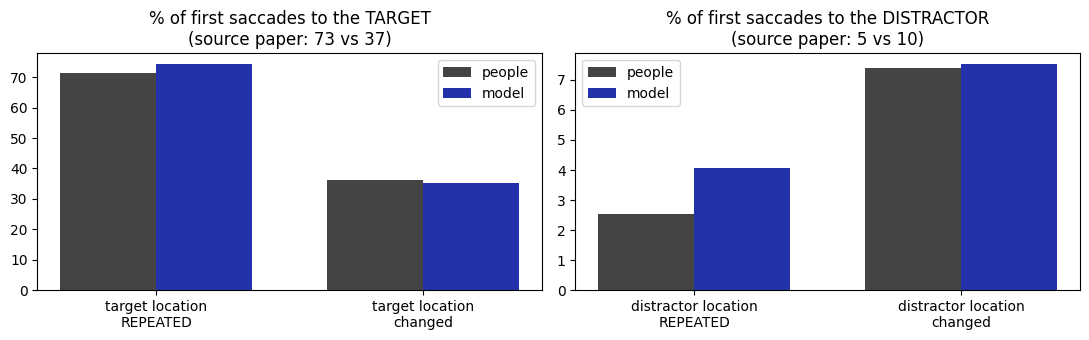

In [17]:
ev2 = ev.copy()
ev2["block"] = pd.to_numeric(ev2["block"], errors="coerce").fillna(0.0)
ev2["trial"] = pd.to_numeric(ev2["trial"], errors="coerce")
ev2["subj"] = ev2["subj"].astype(str)
ev2 = ev2.sort_values(["study", "subj", "block", "trial"])
ev2["prevT"] = ev2.groupby(["study", "subj"]).targLoc.shift(1)
ev2["prevS"] = ev2.groupby(["study", "subj"]).singLoc.shift(1)
key = ["study", "subj", "block", "trial"]
sacc2 = sacc.merge(ev2[key + ["prevT", "prevS"]], on=key, how="left")

def bar_pair(masks, pick, labels, title, paper):
    obs = [((chose[m_] * pick[m_]).sum() / m_.sum() * 100).item()
           for m_ in masks]
    mod = [((prob[m_] * pick[m_]).sum() / m_.sum() * 100).item()
           for m_ in masks]
    x = np.arange(2)
    plt.bar(x - 0.18, obs, 0.36, label="people", color="#444444")
    plt.bar(x + 0.18, mod, 0.36, label="model", color="#2233aa")
    plt.xticks(x, labels); plt.legend()
    plt.title(f"{title}\n{paper}")

plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
tr = test & first & torch.tensor(sacc2.prevT.values == sacc.targLoc.values)
tc_ = test & first & torch.tensor((sacc2.prevT.values != sacc.targLoc.values)
                                  & ~np.isnan(sacc2.prevT.values))
bar_pair([tr, tc_], isT,
         ["target location\nREPEATED", "target location\nchanged"],
         "% of first saccades to the TARGET", "(source paper: 73 vs 37)")
plt.subplot(1, 2, 2)
sr = test & first & sing_present & torch.tensor(
    (sacc2.prevS.values == sacc.singLoc.values) & (sacc2.prevS.values > 0))
sc2 = test & first & sing_present & torch.tensor(
    sacc2.prevS.values != sacc.singLoc.values)
bar_pair([sr, sc2], isS,
         ["distractor location\nREPEATED", "distractor location\nchanged"],
         "% of first saccades to the DISTRACTOR", "(source paper: 5 vs 10)")
plt.tight_layout()
plt.show()

## 11. The spatial prior, trial by trial

Section 4 built the history map with made-up history. Here it is
with the REAL trained memories of one held-out person: before each
display appears, the prior `window x (beta_T*h_T + beta_D*h_D)`
already tilts toward where their last target was. The green circle
marks the PREVIOUS trial's target location — watch the red bump
follow it from trial to trial. The bar on the right quantifies it
across all held-out trials: the prior at the previous target's
location versus the average other location.

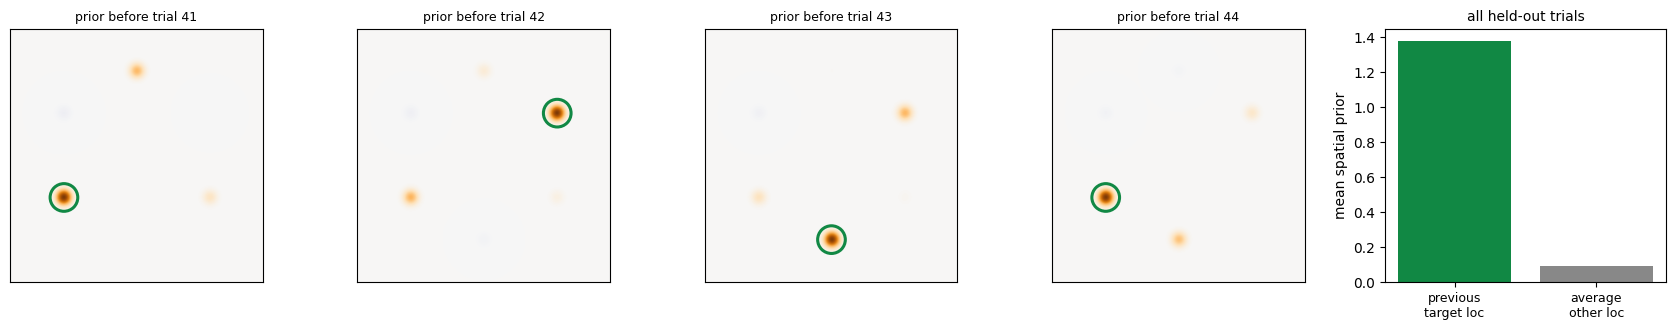

prior at previous target location: +1.375  vs other locations: +0.091


In [18]:
si_np = tt["si"].numpy(); ti_np = tt["ti"].numpy()
subj = int(np.unique(si_np[test.numpy()])[0])       # one held-out person
trials = np.sort(ti_np[(si_np == subj)])[40:44]     # four consecutive trials

with torch.no_grad():
    w_slot = torch.sigmoid(w["k"] * (w["r0"] - 0.5)).item()
    fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
    for ax, t in zip(axes[:4], trials):
        hT_t = memT[subj, t].numpy(); hD_t = memD[subj, t].numpy()
        # the prior, location by location (learned weights)...
        prior_t = w_slot * (learned["beta_T"]*hT_t
                            + learned["beta_D"]*hD_t)
        pm = paint_slots(prior_t)     # ...then painted, display only
        v = max(np.abs(pm).max(), 1e-9)
        ax.imshow(pm, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
        prev = int(tt["eT"][subj, t-1].argmax()) if t > 0 else None
        if prev is not None:
            px, py = (pos[prev][0]+0.75)/1.5*IMG, (pos[prev][1]+0.75)/1.5*IMG
            ax.add_patch(plt.Circle((px, py), 14, fill=False,
                                    ec="#118844", lw=2.2))
        ax.set_title(f"prior before trial {int(t)}", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])

    # across all held-out trials: prior at prev-target loc vs elsewhere
    prior_slots = w_slot * (learned["beta_T"]*memT + learned["beta_D"]*memD)
    at_prev, at_other = [], []
    for s in np.unique(si_np[test.numpy()]):
        eT_s = tt["eT"][int(s)]
        T_ = int(ti_np[si_np == int(s)].max()) + 1
        for t in range(1, T_):
            prev = int(eT_s[t-1].argmax())
            if eT_s[t-1].sum() == 0:
                continue
            vals = prior_slots[int(s), t].numpy()
            at_prev.append(vals[prev])
            at_other.append(np.delete(vals, prev).mean())
    axes[4].bar([0, 1], [np.mean(at_prev), np.mean(at_other)],
                color=["#118844", "#888888"])
    axes[4].set_xticks([0, 1])
    axes[4].set_xticklabels(["previous\ntarget loc", "average\nother loc"],
                            fontsize=9)
    axes[4].set_ylabel("mean spatial prior")
    axes[4].set_title("all held-out trials", fontsize=10)
    plt.tight_layout()
    plt.show()
print(f"prior at previous target location: {np.mean(at_prev):+.3f}  "
      f"vs other locations: {np.mean(at_other):+.3f}")

## Recap

| The model receives | It returns |
| --- | --- |
| a picture, a goal, the trial history | a probability for every item |

We laid out the model structure (§1) and the displays (§2), followed
one display through the maps — raw color contrast, goal-modified
color (`g_T`, `g_D`), shape (`g_F`), and their sum, the goal-modified
salience map (§3) — added the leaky-accumulator selection history
(`eta`, `beta`; §4), assembled the model into combined_map -> priority_map ->
predict_saccade, with a worked raw-image-to-prediction example (§7), trained the nine numbers on the real
first eye movements with the motion-singleton and Stilwell
low-salience trials excluded (§8), evaluated on people the model
never saw with three explained metrics (§9), reproduced the three
signature patterns — suppression, salience-graded suppression out of
sample, and location priming (§10) — and watched the spatial prior
track the previous target location trial by trial (§11).

More: `RESULTS.md` (the full results record) and
`docs/priority_field_visual_search_model.md` (the theory).